In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("bank-full.csv", sep=";")
df.shape

(45211, 17)

In [3]:
df.shape

(45211, 17)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [9]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [10]:
df["y"].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

In [11]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols

/var/folders/_s/l9md4_2x5rj1z5hmcz54bvnr0000gn/T/ipykernel_37183/3728129623.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [12]:
for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print()

job
<ArrowStringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str

marital
<ArrowStringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str

education
<ArrowStringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str

default
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

housing
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

loan
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

contact
<ArrowStringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str

month
<ArrowStringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str

poutcome
<ArrowStringArray>
['unknown', 'failure', 'other', 'success']
Length: 4, dtype: str

y
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str


In [13]:
for col in categorical_cols:
    unknown_count = (df[col] == "unknown").sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"{col}: {unknown_count} ({pct:.1f}%)")

job: 288 (0.6%)
education: 1857 (4.1%)
contact: 13020 (28.8%)
poutcome: 36959 (81.7%)


In [14]:
import matplotlib.pyplot as plt

numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

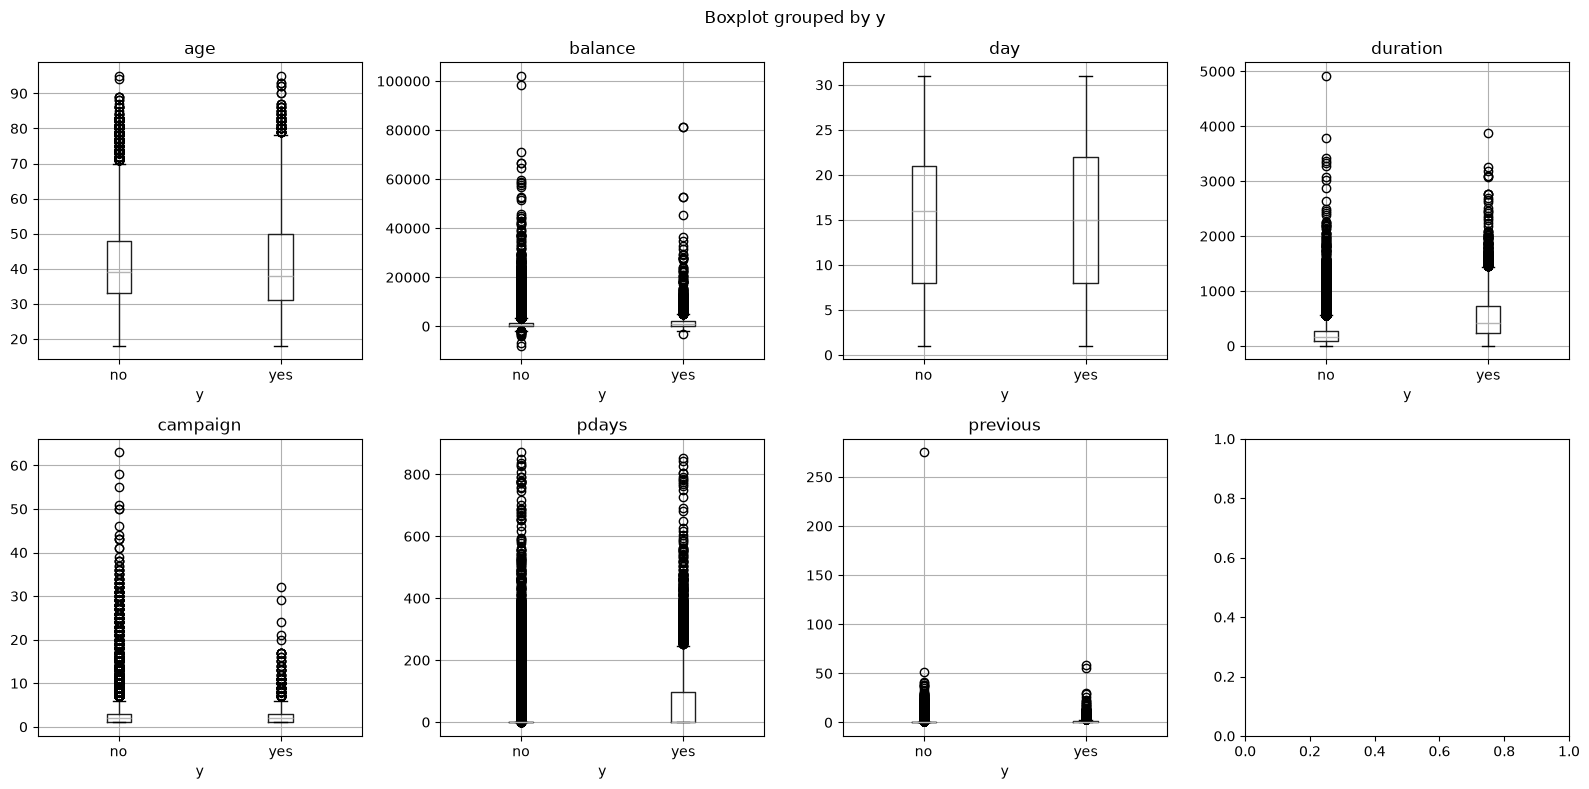

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by="y", ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()